# Method results

Per-method report card. Pick one `METHOD` in the first cell; everything below runs for that method only.

Sections:
1. Simulation results
2. Classifier results
3. Stability diagnostics from resampling
4. Final protein list + enrichment

In [167]:
METHOD = "rf_shap"   # change this to switch the whole notebook

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.styles.colors import CATEGORICAL, PALETTE, SEQUENTIAL_TEAL, SEQUENTIAL_ORANGE
from src.statistics import nadeau_bengio_se

sns.set_theme(style="whitegrid", context="notebook")

RESULTS = REPO_ROOT / "results"
DATA_PROCESSED = REPO_ROOT / "data" / "processed"

STAGE_DIRS = {
    "simulation": RESULTS / "simulation" / METHOD,
    "classifier": RESULTS / "classifier" / METHOD,
    "selection":  RESULTS / "selection" / METHOD,
    "enrichment": RESULTS / "enrichment" / METHOD,
}
missing = [s for s, p in STAGE_DIRS.items() if not p.exists()]
assert not missing, f"Missing result directories for METHOD={METHOD!r}: {missing}"

def load_meta(path: Path) -> dict:
    with open(path) as f:
        return json.load(f)

splits_meta = load_meta(DATA_PROCESSED / "splits_meta.json")
TEST_SIZE = float(splits_meta["test_size"])
N_SAMPLES = int(splits_meta["n_samples"])
N_TEST = int(round(TEST_SIZE * N_SAMPLES))
N_TRAIN = N_SAMPLES - N_TEST

print(f"METHOD = {METHOD}")
for stage, path in STAGE_DIRS.items():
    print(f"  {stage:<10s} -> {path.relative_to(REPO_ROOT)}")
print(
    f"Nadeau-Bengio: n_samples={N_SAMPLES} test_size={TEST_SIZE:.4f} "
    f"-> n_train={N_TRAIN} n_test={N_TEST} (ratio={N_TEST / N_TRAIN:.4f})"
)

output_dir = Path(f"../results/figs/{METHOD}")
output_dir.mkdir(parents=True, exist_ok=True)

METHOD = rf_shap
  simulation -> results\simulation\rf_shap
  classifier -> results\classifier\rf_shap
  selection  -> results\selection\rf_shap
  enrichment -> results\enrichment\rf_shap
Nadeau-Bengio: n_samples=512 test_size=0.2000 -> n_train=410 n_test=102 (ratio=0.2488)


In [168]:
sel_meta = load_meta(STAGE_DIRS["selection"] / "meta.json")
full_meta = load_meta(STAGE_DIRS["selection"] / "full_data_meta.json")
sim_meta = load_meta(STAGE_DIRS["simulation"] / "meta.json")
clf_meta = load_meta(STAGE_DIRS["classifier"] / "meta.json")

header = pd.DataFrame({
    "stage":   ["selection (resampling)", "selection (full data)", "simulation", "classifier"],
    "n_samples":   [sel_meta.get("n_samples"),  full_meta.get("n_samples"),  sim_meta.get("n_samples"),  clf_meta.get("n_samples")],
    "n_proteins":  [sel_meta.get("n_proteins"), full_meta.get("n_proteins"), sim_meta.get("n_proteins"), clf_meta.get("n_proteins")],
    "n_splits":    [sel_meta.get("n_splits"),   None,                         None,                        clf_meta.get("n_splits")],
    "n_significant": [sel_meta.get("method_params", {}).get("n_significant"),
                      full_meta.get("n_significant"),
                      None,
                      None],
    "seed":        [sel_meta.get("seed"), full_meta.get("seed"), sim_meta.get("seed"), clf_meta.get("seed")],
})
header

,stage,n_samples,n_proteins,n_splits,n_significant,seed
0,selection (resampling),512.0,10776.0,50.0,NaN,42
1,selection (full data),512.0,10776.0,NaN,0.0,42
2,simulation,500.0,NaN,NaN,NaN,42
3,classifier,NaN,NaN,50.0,NaN,42


## 1. Simulation results

Synthetic-signal recovery under controlled effect sizes. Higher `recall` at fixed `k` is better; lower `fdp` is better.

In [169]:
recall_df = pd.read_parquet(STAGE_DIRS["simulation"] / "recall.parquet")
fdp_df = pd.read_parquet(STAGE_DIRS["simulation"] / "fdp.parquet")
print(
    f"recall: {len(recall_df):,} rows | repeats={recall_df['repeat'].nunique()} | "
    f"signal_types={sorted(recall_df['signal_type'].unique())} | "
    f"effect_sizes={sorted(recall_df['effect_size'].unique())} | k={sorted(recall_df['k'].unique())}"
)
print(
    f"fdp:    {len(fdp_df):,} rows | repeats={fdp_df['repeat'].nunique()} | k={sorted(fdp_df['k'].unique())}"
)
recall_df.head(10)

recall: 3,750 rows | repeats=50 | signal_types=['bounded_variance', 'linear', 'threshold', 'u_shape', 'xor_pair'] | effect_sizes=[np.float64(0.3), np.float64(0.6), np.float64(1.0)] | k=['10', '100', '25', '50', 'native']
fdp:    250 rows | repeats=50 | k=['10', '100', '25', '50', 'native']


,repeat,signal_type,effect_size,k,recall,block_recall
0,1,bounded_variance,0.3,10,0.0,0.0
1,1,bounded_variance,0.3,100,0.0,0.0
2,1,bounded_variance,0.3,25,0.0,0.0
3,1,bounded_variance,0.3,50,0.0,0.0
4,1,bounded_variance,0.3,native,0.0,0.0
5,1,bounded_variance,0.6,10,0.0,0.0
6,1,bounded_variance,0.6,100,0.0,0.0
7,1,bounded_variance,0.6,25,0.0,0.0
8,1,bounded_variance,0.6,50,0.0,0.0
9,1,bounded_variance,0.6,native,0.0,0.0


In [170]:
recall_summary = (
    recall_df.groupby(["signal_type", "effect_size", "k"], as_index=False)
       .agg(recall_mean=("recall", "mean"), recall_std=("recall", "std"),
            n=("recall", "size"))
)
recall_summary.round(3)

,signal_type,effect_size,k,recall_mean,recall_std,n
0,bounded_variance,0.3,10,0.000,0.000,50
1,bounded_variance,0.3,100,0.053,0.123,50
2,bounded_variance,0.3,25,0.000,0.000,50
3,bounded_variance,0.3,50,0.007,0.047,50
4,bounded_variance,0.3,native,0.000,0.000,50
...,...,...,...,...,...,...
70,xor_pair,1.0,10,0.000,0.000,50
71,xor_pair,1.0,100,0.003,0.024,50
72,xor_pair,1.0,25,0.003,0.024,50
73,xor_pair,1.0,50,0.003,0.024,50


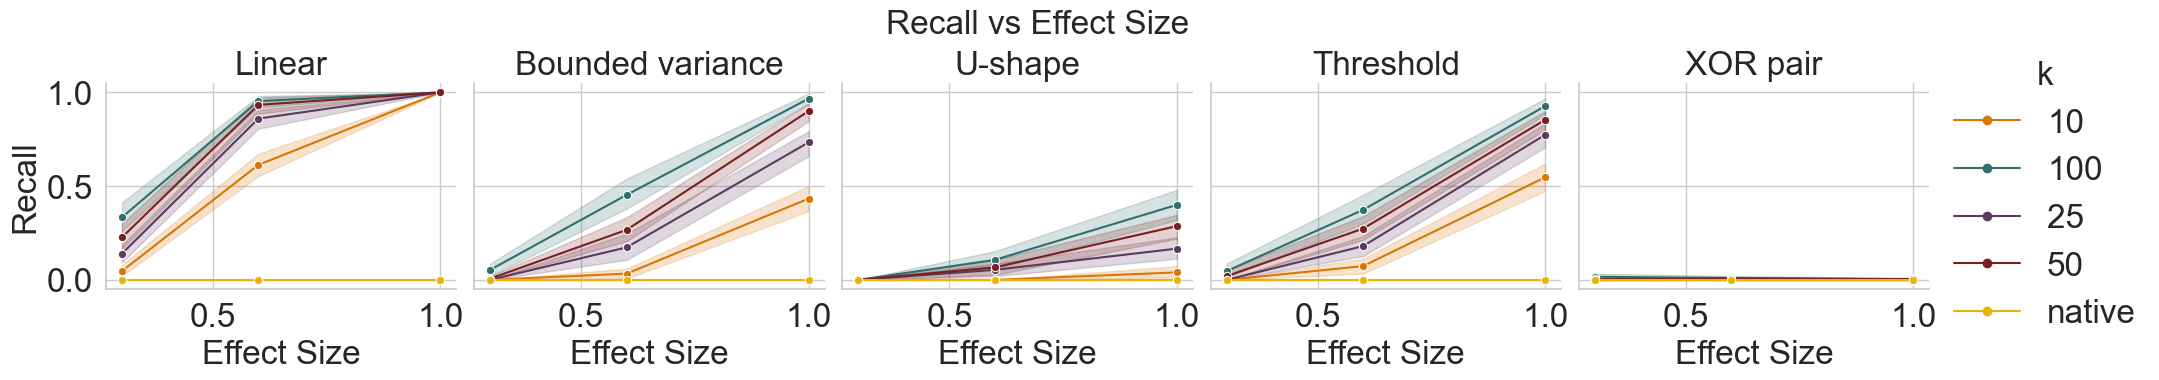

In [171]:
def plot_recall_vs_effect_size(recall_df, show_native=True):
    FONTSIZE_TITLE   = 24
    FONTSIZE_SUBPLOT = 24
    FONTSIZE_LABEL   = 24
    FONTSIZE_TICK    = 24
    FONTSIZE_LEGEND  = 24

    if not show_native:
        recall_df = recall_df[recall_df["k"] != "native"].copy()

    k_values  = sorted(recall_df["k"].unique())
    palette_k = dict(zip(k_values, CATEGORICAL[:len(k_values)]))

    desired_signal_order = ["linear", "bounded_variance", "u_shape", "threshold", "xor_pair"]
    existing_signal_types = list(pd.unique(recall_df["signal_type"]))
    signal_order = [s for s in desired_signal_order if s in existing_signal_types]
    signal_order += [s for s in existing_signal_types if s not in signal_order]

    g = sns.relplot(
        data=recall_df, kind="line",
        x="effect_size", y="recall", hue="k", col="signal_type",
        col_order=signal_order,
        palette=palette_k, marker="o", errorbar=("ci", 95), height=3.2, aspect=1.2,
        facet_kws={"sharey": True},
    )
    g.set_axis_labels("Effect Size", "Recall", fontsize=FONTSIZE_LABEL)
    g.set_titles(col_template="{col_name}")

    title_map = {
        "linear": "Linear",
        "bounded_variance": "Bounded variance",
        "threshold": "Threshold",
        "u_shape": "U-shape",
        "xor_pair": "XOR pair",
    }
    for ax in g.axes.flat:
        raw_title = ax.get_title()
        if raw_title in title_map:
            ax.set_title(title_map[raw_title], fontsize=FONTSIZE_SUBPLOT)
        else:
            fallback = raw_title.replace("_", " ").replace("-", " ")
            ax.set_title(
                fallback[:1].upper() + fallback[1:] if fallback else fallback,
                fontsize=FONTSIZE_SUBPLOT
            )
        ax.tick_params(axis="both", labelsize=FONTSIZE_TICK)

    g._legend.get_title().set_fontsize(FONTSIZE_LEGEND)
    for text in g._legend.get_texts():
        text.set_fontsize(FONTSIZE_LEGEND)

    g.fig.suptitle("Recall vs Effect Size", y=1.08, fontsize=FONTSIZE_TITLE)
    g.fig.subplots_adjust(top=0.85)
    sns.move_legend(g, loc="center right", bbox_to_anchor=(1.06, 0.5), fontsize = FONTSIZE_LEGEND)

    g.fig.savefig(output_dir / f"{METHOD}_recall_vs_effect.pdf", bbox_inches="tight", dpi=300)
    plt.show()


# Kör utan native (rf_shap)
#plot_recall_vs_effect_size(recall_df, show_native=False)

# Kör med native (t-test, MI)
plot_recall_vs_effect_size(recall_df, show_native=True)

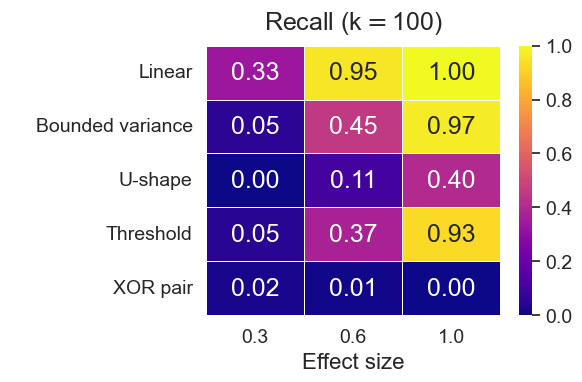

In [190]:
FONTSIZE_TITLE  = 18
FONTSIZE_LABEL  = 16
FONTSIZE_TICK   = 14
FONTSIZE_ANNOT  = 18

desired_signal_order = ["linear", "bounded_variance", "u_shape", "threshold", "xor_pair"]
existing_signal_types = list(pd.unique(recall_df["signal_type"]))
signal_order = [s for s in desired_signal_order if s in existing_signal_types]
signal_order += [s for s in existing_signal_types if s not in signal_order]

k = "100"
sim_native = recall_df[recall_df["k"] == k]

title_map = {
    "linear": "Linear",
    "bounded_variance": "Bounded variance",
    "threshold": "Threshold",
    "u_shape": "U-shape",
    "xor_pair": "XOR pair",
}

fig, ax = plt.subplots(figsize=(6, 4))
pivot = (
    sim_native.groupby(["signal_type", "effect_size"])["recall"].mean()
    .unstack("effect_size")
)
pivot.rename(index=title_map, inplace=True)
pivot = pivot.reindex([title_map[s] for s in signal_order if s in title_map])
sns.heatmap(
    pivot, annot=True, fmt=".2f",
    cmap=sns.color_palette("plasma", as_cmap=True),
    ax=ax, vmin=0, vmax=1, cbar_kws={"shrink": 1},
    annot_kws={"size": FONTSIZE_ANNOT},
    linewidths=0.5, linecolor="white",
)
ax.set_title(rf"Recall (k$=${k})", fontsize=FONTSIZE_TITLE, y=1.03)
ax.set_xlabel("Effect size", fontsize=FONTSIZE_LABEL)
ax.set_ylabel(" ", fontsize=FONTSIZE_LABEL)
ax.tick_params(axis="both", labelsize=FONTSIZE_TICK)
ax.collections[0].colorbar.ax.tick_params(labelsize=FONTSIZE_TICK)
fig.tight_layout()

fig.savefig(output_dir / f"{METHOD}_recall_heatmap_k{ k }.pdf", bbox_inches="tight", dpi=300)
plt.show()

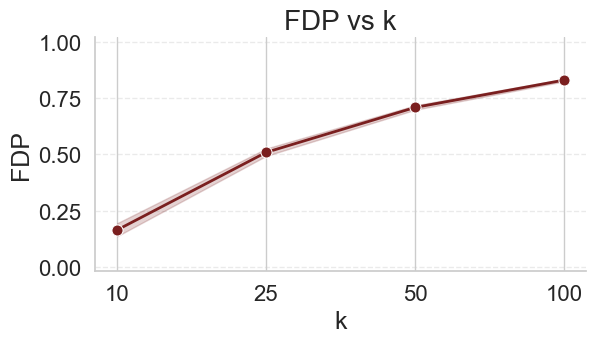

,k,fdp_mean,fdp_std,n_selected_mean
0,10,0.164,0.106,10.0
1,25,0.509,0.064,25.0
2,50,0.708,0.036,50.0
3,100,0.830,0.021,100.0
4,native,NaN,NaN,0.0


In [173]:
FONTSIZE_TITLE  = 20
FONTSIZE_LABEL  = 18
FONTSIZE_TICK   = 16

def _k_sort_key(value):
    s = str(value).strip().lower()
    if s == "native":
        return (2, float("inf"))
    try:
        return (0, float(s))
    except ValueError:
        return (1, s)

k_order = sorted(pd.unique(fdp_df["k"]), key=_k_sort_key)

fdp_plot = fdp_df.copy()
fdp_plot["k"] = pd.Categorical(fdp_plot["k"], categories=k_order, ordered=True)
fdp_plot = fdp_plot.sort_values("k")

fig, ax = plt.subplots(figsize=(6, 3.6))
sns.lineplot(
    data=fdp_plot, x="k", y="fdp", estimator="mean", errorbar=("ci", 95),
    marker="o", color=PALETTE["danger"], ax=ax,
    linewidth=2, markersize=8,
)
ax.set_title(r"FDP vs k", fontsize=FONTSIZE_TITLE)
ax.set_xlabel(r"k", fontsize=FONTSIZE_LABEL)
ax.set_ylabel("FDP", fontsize=FONTSIZE_LABEL)
ax.set_ylim(-0.02, 1.02)
ax.tick_params(axis="both", labelsize=FONTSIZE_TICK)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.tight_layout()

fig.savefig(output_dir / f"{METHOD}_fdp_vs_k.pdf", bbox_inches="tight", dpi=300)
plt.show()

(
    fdp_plot.groupby("k", as_index=False, sort=False, observed=True)
    .agg(fdp_mean=("fdp", "mean"), fdp_std=("fdp", "std"),
         n_selected_mean=("n_selected", "mean"))
    .round(3)
)

## 2. Classifier results

Downstream classifier performance when trained on the top-k features selected by this method on each resampled split.

`auc_se_nb` / `aupr_se_nb` are Nadeau–Bengio corrected standard errors of the mean across the random 80/20 splits, accounting for shared test patients across folds. `auc_sd_split` / `aupr_sd_split` show the raw split-to-split spread (variability of the per-split metric, not population SE).

In [174]:
clf = pd.read_parquet(STAGE_DIRS["classifier"] / "scores.parquet")
print(f"{len(clf):,} rows | splits={clf['split_id'].nunique()} | classifiers={sorted(clf['classifier'].unique())} | "
      f"k={sorted(clf['k'].unique())}")
clf.head()

750 rows | splits=50 | classifiers=['LogisticRegression', 'RandomForest', 'XGBoost'] | k=['10', '100', '25', '50', 'native']


,split_id,classifier,k,auc,aupr,n_features_actual
0,0,LogisticRegression,10,0.634091,0.274940,10
1,0,RandomForest,10,0.625000,0.276484,10
2,0,XGBoost,10,0.703030,0.356310,10
3,0,LogisticRegression,25,0.574242,0.275151,25
4,0,RandomForest,25,0.569697,0.252891,25


In [175]:
clf_summary = (
    clf.groupby(["classifier", "k"], as_index=False)
       .agg(auc_mean=("auc", "mean"), auc_sd_split=("auc", "std"),
            aupr_mean=("aupr", "mean"), aupr_sd_split=("aupr", "std"),
            n_splits=("split_id", "nunique"),
            n=("auc", "size"))
       .sort_values(["classifier", "k"])
)
clf_summary["auc_se_nb"] = clf_summary.apply(
    lambda r: nadeau_bengio_se(r["auc_sd_split"], int(r["n_splits"]), N_TRAIN, N_TEST),
    axis=1,
)
clf_summary["aupr_se_nb"] = clf_summary.apply(
    lambda r: nadeau_bengio_se(r["aupr_sd_split"], int(r["n_splits"]), N_TRAIN, N_TEST),
    axis=1,
)
clf_summary.round(3).style.background_gradient(subset=["auc_mean", "aupr_mean"], cmap="YlGnBu")

,classifier,k,auc_mean,auc_sd_split,aupr_mean,aupr_sd_split,n_splits,n,auc_se_nb,aupr_se_nb
0,LogisticRegression,10,0.605000,0.072000,0.248000,0.073000,50,50,0.037000,0.038000
1,LogisticRegression,100,0.589000,0.067000,0.219000,0.054000,50,50,0.035000,0.028000
2,LogisticRegression,25,0.631000,0.071000,0.259000,0.077000,50,50,0.037000,0.040000
3,LogisticRegression,50,0.609000,0.075000,0.237000,0.064000,50,50,0.039000,0.033000
4,LogisticRegression,native,nan,nan,nan,nan,50,50,nan,nan
5,RandomForest,10,0.640000,0.073000,0.268000,0.075000,50,50,0.038000,0.039000
6,RandomForest,100,0.662000,0.066000,0.255000,0.067000,50,50,0.034000,0.035000
7,RandomForest,25,0.666000,0.069000,0.269000,0.076000,50,50,0.036000,0.039000
8,RandomForest,50,0.667000,0.065000,0.267000,0.070000,50,50,0.034000,0.036000
9,RandomForest,native,nan,nan,nan,nan,50,50,nan,nan


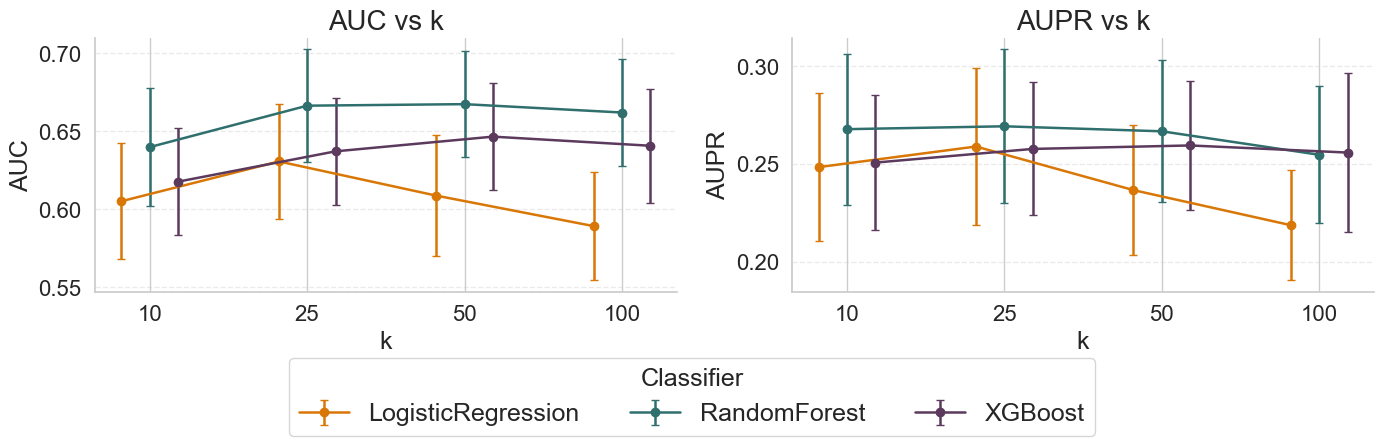

In [176]:
FONTSIZE_TITLE  = 20
FONTSIZE_LABEL  = 18
FONTSIZE_TICK   = 16
FONTSIZE_LEGEND = 18

INCLUDE_NATIVE = False

classifier_order = sorted(clf["classifier"].unique())
palette_clf = dict(zip(classifier_order, CATEGORICAL[:len(classifier_order)]))

k_unique = list(pd.unique(clf["k"]))
def _find_k(s):
    for v in k_unique:
        if str(v).strip().lower() == str(s).strip().lower():
            return v
    return None
desired = ['10', '25', '50', '100', 'native']
k_order_clf = [v for s in desired if (v := _find_k(s)) is not None]
k_order_clf += [v for v in k_unique if v not in k_order_clf]

if not INCLUDE_NATIVE and "native" in k_order_clf:
    k_order_clf = k_order_clf[:-1]

x_positions = np.arange(len(k_order_clf))
dodge = 0.18

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), sharex=True)
handles, labels = [], []

for ax, metric, ylabel in [(axes[0], "auc", "AUC"), (axes[1], "aupr", "AUPR")]:
    mean_col = f"{metric}_mean"
    se_col   = f"{metric}_se_nb"
    for i, clf_name in enumerate(classifier_order):
        sub  = clf_summary[clf_summary["classifier"] == clf_name].set_index("k")
        y    = [sub.loc[k, mean_col] if k in sub.index else np.nan for k in k_order_clf]
        yerr = [sub.loc[k, se_col]   if k in sub.index else np.nan for k in k_order_clf]
        offset = (i - (len(classifier_order) - 1) / 2) * dodge
        line = ax.errorbar(
            x_positions + offset, y, yerr=yerr,
            fmt="o-", color=palette_clf[clf_name],
            label=clf_name, capsize=3, linewidth=1.8, markersize=6,
        )
        # Collect handles only from first axis to avoid duplicates
        if ax == axes[0]:
            handles.append(line)
            labels.append(clf_name)

    ax.set_ylabel(ylabel, fontsize=FONTSIZE_LABEL)
    ax.set_xlabel(r"k", fontsize=FONTSIZE_LABEL)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(k_order_clf, fontsize=FONTSIZE_TICK)
    ax.tick_params(axis="y", labelsize=FONTSIZE_TICK)
    ax.set_title(f"{ylabel} vs k", fontsize=FONTSIZE_TITLE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# Single shared legend to the right of the figure
fig.legend(
    handles, labels,
    title="Classifier",
    fontsize=FONTSIZE_LEGEND,
    title_fontsize=FONTSIZE_LEGEND,
    frameon=True,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.07),
    ncol=len(classifier_order),  # alla på en rad
)

fig.tight_layout()

fig.savefig(output_dir / f"{METHOD}_clf_performance.pdf", bbox_inches="tight", dpi=300)
plt.show()

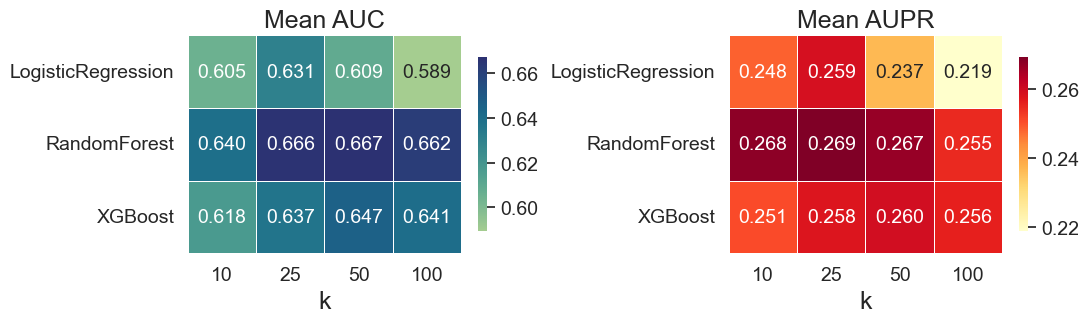

In [177]:
FONTSIZE_TITLE  = 18
FONTSIZE_LABEL  = 18
FONTSIZE_TICK   = 14
FONTSIZE_ANNOT  = 14

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, metric, cmap, title in [
    (axes[0], "auc",  sns.color_palette("crest", as_cmap=True), "Mean AUC"),
    (axes[1], "aupr", "YlOrRd", "Mean AUPR"),
]:
    drop_native = True

    pivot = clf.groupby(["classifier", "k"])[metric].mean().unstack("k")
    if drop_native and "native" in pivot.columns:
        pivot = pivot.drop(columns="native")
    cols = [k for k in k_order_clf if not (drop_native and str(k).lower() == "native")]
    pivot = pivot.reindex(index=classifier_order, columns=cols)

    sns.heatmap(
        pivot, annot=True, fmt=".3f", cmap=cmap, ax=ax,
        cbar_kws={"shrink": 0.8},
        annot_kws={"size": FONTSIZE_ANNOT},
        linewidths=0.5, linecolor="white",
    )
    ax.set_title(title, fontsize=FONTSIZE_TITLE)
    ax.set_xlabel("k", fontsize=FONTSIZE_LABEL)
    ax.set_ylabel("", fontsize=FONTSIZE_LABEL)
    ax.tick_params(axis="both", labelsize=FONTSIZE_TICK)
    ax.collections[0].colorbar.ax.tick_params(labelsize=FONTSIZE_TICK)

fig.tight_layout()
fig.savefig(output_dir / f"{METHOD}_clf_heatmap.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 3. Stability diagnostics

How often each protein was selected across the resampled splits.
- `stability_significant.parquet` â€” frequency under the significance-threshold rule
- `stability_topk.parquet` â€” frequency for k âˆˆ {10, 25, 50, 100}

At the end of this section we overlay the final protein list (from Section 4) on the stability curves, so you can see whether the final picks came from the stable tail or not.

In [178]:
stab_sig = pd.read_parquet(STAGE_DIRS["selection"] / "stability_significant.parquet")
stab_topk = pd.read_parquet(STAGE_DIRS["selection"] / "stability_topk.parquet")

# Final protein list is defined by full_data_ranking.significant and is used in Section 4 as well.
ranking = pd.read_parquet(STAGE_DIRS["selection"] / "full_data_ranking.parquet")
final_list = ranking[ranking["significant"]].sort_values("rank").reset_index(drop=True)
final_ids = set(final_list["protein_id"])

print(f"significant-rule: {len(stab_sig):,} proteins observed with frequency>0")
print(f"top-k:            {len(stab_topk):,} rows across k={sorted(stab_topk['k'].unique())}")
print(f"final list size:  {len(final_list)} proteins")

significant-rule: 10,776 proteins observed with frequency>0
top-k:            43,104 rows across k=[np.int64(10), np.int64(25), np.int64(50), np.int64(100)]
final list size:  13 proteins


C:\Users\Love\AppData\Local\Temp\ipykernel_22628\4276785.py:11: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


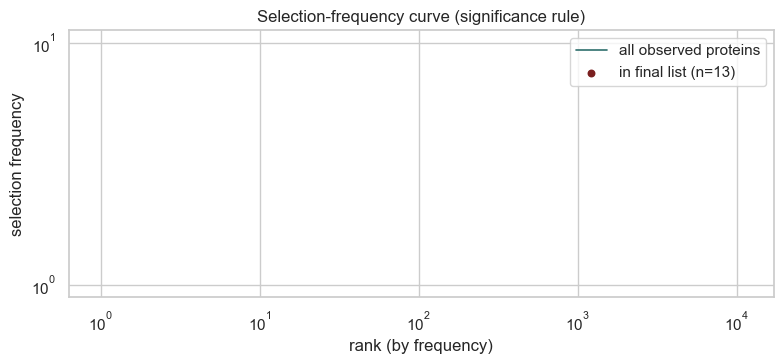

final-list proteins that appear in stability_significant: 13/13


In [179]:
curve = stab_sig.sort_values("frequency", ascending=False).reset_index(drop=True)
curve["rank"] = np.arange(1, len(curve) + 1)
curve["in_final_list"] = curve["protein_id"].isin(final_ids)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(curve["rank"], curve["frequency"], color=PALETTE["secondary"], lw=1.2, label="all observed proteins")
hit = curve[curve["in_final_list"]]
ax.scatter(hit["rank"], hit["frequency"], color=PALETTE["danger"], s=22, zorder=5,
           label=f"in final list (n={len(hit)})")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("rank (by frequency)")
ax.set_ylabel("selection frequency")
ax.set_title(f"Selection-frequency curve (significance rule)")
ax.legend()
fig.tight_layout()
plt.show()

n_final_observed = curve["in_final_list"].sum()
print(f"final-list proteins that appear in stability_significant: {n_final_observed}/{len(final_list)}")

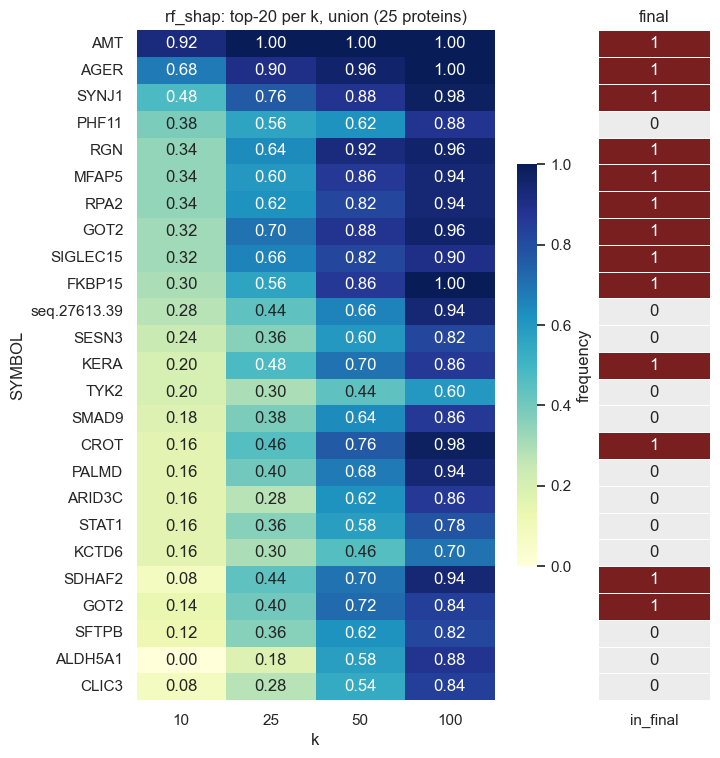

In [180]:
# Boolean to include native or not
SHOW_NATIVE = False  # set to True to include native column

topN   = 20
k_vals = sorted(stab_topk["k"].unique())
native_col = "native"

def _normalize_probe_id(value) -> str:
    probe = str(value).strip()
    if probe.startswith("seq."):
        probe = probe[4:]
    return probe.replace("_", "-").replace(".", "-")

ann_map = pd.read_csv(DATA_PROCESSED / "somalogic_annotation.csv", usecols=["PROBEID", "SYMBOL"])
ann_map["probe_norm"] = ann_map["PROBEID"].map(_normalize_probe_id)
symbol_lookup = (
    ann_map.dropna(subset=["SYMBOL"])
    .drop_duplicates("probe_norm")
    .set_index("probe_norm")["SYMBOL"]
)

top_union_k = (
    stab_topk.sort_values(["k", "frequency"], ascending=[True, False])
    .groupby("k").head(topN)["protein_id"].tolist()
)

if SHOW_NATIVE:
    top_union_native = (
        stab_sig.sort_values("frequency", ascending=False)
        .head(topN)["protein_id"].tolist()
    )
    top_union = list(dict.fromkeys(top_union_k + top_union_native))
else:
    top_union = list(dict.fromkeys(top_union_k))

mat = (
    stab_topk[stab_topk["protein_id"].isin(top_union)]
    .pivot_table(index="protein_id", columns="k", values="frequency", fill_value=0)
    .reindex(top_union)
)

if SHOW_NATIVE:
    mat[native_col] = (
        mat.index.to_series()
        .map(stab_sig.set_index("protein_id")["frequency"])
        .fillna(0.0)
    )

mat["in_final"] = mat.index.to_series().isin(final_ids).astype(int)

display_cols = ([native_col] if SHOW_NATIVE else []) + k_vals
row_labels   = [symbol_lookup.get(_normalize_probe_id(pid), pid) for pid in mat.index]
mat_display  = mat.copy()
mat_display.index = row_labels

fig, (ax_hm, ax_flag) = plt.subplots(
    1, 2, figsize=(1.1 * len(display_cols) + 3, 0.3 * len(mat_display) + 1.2),
    gridspec_kw={"width_ratios": [len(display_cols), 1], "wspace": 0.05},
)
sns.heatmap(
    mat_display[display_cols],
    annot=True, fmt=".2f", cmap="YlGnBu",
    vmin=0, vmax=mat_display[display_cols].values.max(),
    ax=ax_hm, cbar_kws={"shrink": 0.6, "label": "frequency"},
)
ax_hm.set_title(f"{METHOD}: top-{topN} per {'native/' if SHOW_NATIVE else ''}k, union ({len(mat_display)} proteins)")
ax_hm.set_xlabel("native / k" if SHOW_NATIVE else "k")
ax_hm.set_ylabel("SYMBOL")

sns.heatmap(
    mat_display[["in_final"]],
    annot=True, fmt="d",
    cmap=["#ECECEC", PALETTE["danger"]],
    cbar=False, ax=ax_flag,
    linewidths=0.4, linecolor="white",
)
ax_flag.set_yticks([])
ax_flag.set_xlabel("")
ax_flag.set_title("final")
plt.show()

In [181]:
thresholds = [0.1, 0.2, 0.3, 0.5]

sig_counts = {f"freq>={t}": int((stab_sig["frequency"] >= t).sum()) for t in thresholds}
topk_counts = (
    stab_topk.groupby("k")
             .apply(lambda g: pd.Series({f"freq>={t}": int((g["frequency"] >= t).sum()) for t in thresholds}))
)
summary = pd.concat(
    [pd.DataFrame([sig_counts], index=["significant"]), topk_counts.rename(lambda k: f"top-{k}")]
)
print("Proteins crossing frequency thresholds:")
display(summary)

print("\nmean_rank / mean_score (significant rule):")
display(stab_sig[["frequency", "mean_rank", "mean_score"]].describe().round(3))

Proteins crossing frequency thresholds:


,freq>=0.1,freq>=0.2,freq>=0.3,freq>=0.5
significant,0,0,0,0
top-10,26,14,10,2
top-25,64,32,27,10
top-50,118,65,41,29
top-100,249,129,88,45



mean_rank / mean_score (significant rule):


,frequency,mean_rank,mean_score
count,10776.0,10776.000,10776.000
mean,0.0,5387.500,0.000
std,0.0,2355.884,0.000
min,0.0,4.100,0.000
25%,0.0,3642.455,0.000
50%,0.0,5644.220,0.000
75%,0.0,7203.050,0.000
max,0.0,10377.500,0.001


## 4. Final protein list and enrichment

The final list is `significant == True` in `full_data_ranking.parquet` â€” i.e. the method's selection when run on the full (non-resampled) cohort. Enrichment below is whatever was produced against that list.

In [182]:
def _normalize_probe_id(value) -> str:
    probe = str(value).strip()
    if probe.startswith("seq."):
        probe = probe[4:]
    return probe.replace("_", "-").replace(".", "-")

ann = pd.read_csv(DATA_PROCESSED / "somalogic_annotation.csv")
ann["probe_norm"] = ann["PROBEID"].map(_normalize_probe_id)

final = final_list.copy()
final["probe_norm"] = final["protein_id"].map(_normalize_probe_id)
final = final.merge(
    ann[["probe_norm", "SYMBOL", "UNIPROT", "GENENAME"]],
    on="probe_norm", how="left",
).drop(columns="probe_norm")

# Join resampling frequency so the reader sees how stable each final protein is.
final = final.merge(
    stab_sig[["protein_id", "frequency"]].rename(columns={"frequency": "resample_freq"}),
    on="protein_id", how="left",
)
final["resample_freq"] = final["resample_freq"].fillna(0.0)

print(f"{len(final)} final proteins | symbols mapped: {final['SYMBOL'].notna().sum()} | "
      f"mean resample frequency: {final['resample_freq'].mean():.3f}")
display(final[["rank", "protein_id", "SYMBOL", "GENENAME", "score", "q_value", "resample_freq"]]
        .round(4)
        .style.background_gradient(subset=["resample_freq"], cmap="YlGnBu"))

13 final proteins | symbols mapped: 13 | mean resample frequency: 0.000


,rank,protein_id,SYMBOL,GENENAME,score,q_value,resample_freq
0,0,seq.21240.6,AMT,aminomethyltransferase,0.001600,nan,0.000000
1,1,seq.4125.52,AGER,advanced glycosylation end-product specific receptor,0.001500,nan,0.000000
2,2,seq.29150.106,SYNJ1,synaptojanin 1,0.001200,nan,0.000000
3,3,seq.19264.6,RPA2,replication protein A2,0.001200,nan,0.000000
4,4,seq.24943.117,FKBP15,FKBP prolyl isomerase family member 15,0.001100,nan,0.000000
5,5,seq.10847.1,SIGLEC15,sialic acid binding Ig like lectin 15,0.001100,nan,0.000000
6,6,seq.6440.31,MFAP5,microfibril associated protein 5,0.001100,nan,0.000000
7,7,seq.23224.11,RGN,regucalcin,0.001000,nan,0.000000
8,9,seq.10758.2,KERA,keratocan,0.001000,nan,0.000000
9,10,seq.23903.3,GOT2,glutamic-oxaloacetic transaminase 2,0.000900,nan,0.000000


In [183]:
# ── Final list för RF+SHAP baserat på stability selection ────────────────────
def _normalize_probe_id(value) -> str:
    probe = str(value).strip()
    if probe.startswith("seq."):
        probe = probe[4:]
    return probe.replace("_", "-").replace(".", "-")

ann = pd.read_csv(DATA_PROCESSED / "somalogic_annotation.csv")
ann["probe_norm"] = ann["PROBEID"].map(_normalize_probe_id)

# Hämta final list från full_data_ranking — significant=True satt av 02_5
full_data = pd.read_parquet(STAGE_DIRS["selection"] / "full_data_ranking.parquet")
final_list_rf = full_data[full_data["significant"] == True].copy()

print(f"Antal significant proteiner: {len(final_list_rf)}")

# Annotera med symboler
final_list_rf["probe_norm"] = final_list_rf["protein_id"].map(_normalize_probe_id)
final_rf = final_list_rf.merge(
    ann[["probe_norm", "SYMBOL", "UNIPROT", "GENENAME"]],
    on="probe_norm", how="left",
).drop(columns="probe_norm")

# Lägg till stability frequency från full_data_ranking
final_rf = final_rf.rename(columns={"frequency": "resample_freq"})
final_rf["resample_freq"] = final_rf["resample_freq"].fillna(0.0)

print(f"{len(final_rf)} final proteins | "
      f"symbols mapped: {final_rf['SYMBOL'].notna().sum()} | "
      f"mean resample frequency: {final_rf['resample_freq'].mean():.3f}")

display(final_rf[["rank", "protein_id", "SYMBOL", "GENENAME", "score", "resample_freq"]]
        .round(4)
        .style.background_gradient(subset=["resample_freq"], cmap="YlGnBu"))

# ── Enrichment på final list ──────────────────────────────────────────────────
gene_list_rf = final_rf["SYMBOL"].dropna().unique().tolist()
print(f"\nGene list för enrichment: {len(gene_list_rf)} symboler")
print(gene_list_rf)

Antal significant proteiner: 13
13 final proteins | symbols mapped: 13 | mean resample frequency: 0.837


,rank,protein_id,SYMBOL,GENENAME,score,resample_freq
0,0,seq.21240.6,AMT,aminomethyltransferase,0.001600,1.000000
1,1,seq.4125.52,AGER,advanced glycosylation end-product specific receptor,0.001500,0.960000
2,2,seq.29150.106,SYNJ1,synaptojanin 1,0.001200,0.880000
3,3,seq.19264.6,RPA2,replication protein A2,0.001200,0.820000
4,4,seq.24943.117,FKBP15,FKBP prolyl isomerase family member 15,0.001100,0.860000
5,5,seq.10847.1,SIGLEC15,sialic acid binding Ig like lectin 15,0.001100,0.820000
6,6,seq.6440.31,MFAP5,microfibril associated protein 5,0.001100,0.860000
7,7,seq.23224.11,RGN,regucalcin,0.001000,0.920000
8,9,seq.10758.2,KERA,keratocan,0.001000,0.700000
9,10,seq.23903.3,GOT2,glutamic-oxaloacetic transaminase 2,0.000900,0.880000



Gene list för enrichment: 12 symboler
['AMT', 'AGER', 'SYNJ1', 'RPA2', 'FKBP15', 'SIGLEC15', 'MFAP5', 'RGN', 'KERA', 'GOT2', 'CROT', 'SDHAF2']


In [184]:
with open(STAGE_DIRS["enrichment"] / "gene_list.json") as f:
    gene_list = json.load(f)

print(f"source: {gene_list['source']}  min_size={gene_list['min_size']}  "
      f"n_proteins={gene_list['n_proteins']}  n_genes={gene_list['n_genes']}")

enrich_proteins = set(gene_list["protein_ids"])
only_final = enrich_proteins ^ set(final["protein_id"])
if only_final:
    print(f"NOTE: {len(only_final)} proteins differ between final list and enrichment input: {sorted(only_final)[:10]}")
else:
    print("Enrichment input matches the final list exactly.")

source: significant  min_size=10  n_proteins=13  n_genes=12
Enrichment input matches the final list exactly.


In [185]:
with open(STAGE_DIRS["enrichment"] / "gene_list.json") as f:
    gene_list = json.load(f)

enrich_ids = list(gene_list["protein_ids"])
source = gene_list["source"]
print(f"source: {source}  n_proteins={len(enrich_ids)}")

if source == "topk_fallback":
    freq_src = (
        stab_topk[stab_topk["k"] == 10][["protein_id", "frequency"]]
        .rename(columns={"frequency": "resample_freq"})
    )
    freq_label = "resample_freq (top-10)"
else:
    freq_src = stab_sig[["protein_id", "frequency"]].rename(columns={"frequency": "resample_freq"})
    freq_label = "resample_freq (significant)"

enrich_tbl = (
    ranking[ranking["protein_id"].isin(enrich_ids)]
    .copy()
    .sort_values("rank")
    .reset_index(drop=True)
)
enrich_tbl["probe_norm"] = enrich_tbl["protein_id"].map(_normalize_probe_id)
enrich_tbl = enrich_tbl.merge(
    ann[["probe_norm", "SYMBOL", "UNIPROT", "GENENAME"]],
    on="probe_norm", how="left",
).drop(columns="probe_norm")
enrich_tbl = enrich_tbl.merge(freq_src, on="protein_id", how="left")
enrich_tbl["resample_freq"] = enrich_tbl["resample_freq"].fillna(0.0)

print(f"frequency source: {freq_label}")
cols = ["rank", "protein_id", "SYMBOL", "GENENAME", "score", "q_value", "resample_freq"]
cols = [c for c in cols if c in enrich_tbl.columns]
display(enrich_tbl[cols]
        .round(4)
        .style.background_gradient(subset=["resample_freq"], cmap="YlGnBu"))

source: significant  n_proteins=13
frequency source: resample_freq (significant)


,rank,protein_id,SYMBOL,GENENAME,score,q_value,resample_freq
0,0,seq.21240.6,AMT,aminomethyltransferase,0.001600,nan,0.000000
1,1,seq.4125.52,AGER,advanced glycosylation end-product specific receptor,0.001500,nan,0.000000
2,2,seq.29150.106,SYNJ1,synaptojanin 1,0.001200,nan,0.000000
3,3,seq.19264.6,RPA2,replication protein A2,0.001200,nan,0.000000
4,4,seq.24943.117,FKBP15,FKBP prolyl isomerase family member 15,0.001100,nan,0.000000
5,5,seq.10847.1,SIGLEC15,sialic acid binding Ig like lectin 15,0.001100,nan,0.000000
6,6,seq.6440.31,MFAP5,microfibril associated protein 5,0.001100,nan,0.000000
7,7,seq.23224.11,RGN,regucalcin,0.001000,nan,0.000000
8,9,seq.10758.2,KERA,keratocan,0.001000,nan,0.000000
9,10,seq.23903.3,GOT2,glutamic-oxaloacetic transaminase 2,0.000900,nan,0.000000


In [186]:
libraries = sorted(p.name for p in STAGE_DIRS["enrichment"].iterdir() if p.is_dir() and not p.name.startswith("_"))
print("enrichment libraries:", libraries)

rows = []
for lib in libraries:
    bes_path = STAGE_DIRS["enrichment"] / lib / "bes_components.json"
    if not bes_path.exists():
        print(f"[skip] {lib}: bes_components.json missing")
        continue
    bes = load_meta(bes_path)
    rows.append({
        "library": lib,
        "gene_list_size": bes.get("gene_list_size"),
        "background_size": bes.get("background_size"),
        "bes_raw": bes.get("bes_raw"),
        "bes_z":   bes.get("bes_z"),
        "bes_p_emp": bes.get("bes_p_emp"),
        "n_significant_terms": bes.get("bes_components", {}).get("n_significant_terms"),
        "n_terms_input":       bes.get("bes_components", {}).get("n_terms_input"),
    })
bes_df = pd.DataFrame(rows)
bes_df.round(3).style.background_gradient(subset=["bes_z"], cmap="YlGnBu")

enrichment libraries: ['GO_Biological_Process_2025', 'KEGG_2026', 'Reactome_Pathways_2024']


,library,gene_list_size,background_size,bes_raw,bes_z,bes_p_emp,n_significant_terms,n_terms_input
0,GO_Biological_Process_2025,12,9511,0.000000,-0.314000,1.000000,0,126
1,KEGG_2026,12,9511,0.000000,-0.197000,1.000000,0,24
2,Reactome_Pathways_2024,12,9511,1.789000,0.001000,0.112000,1,144


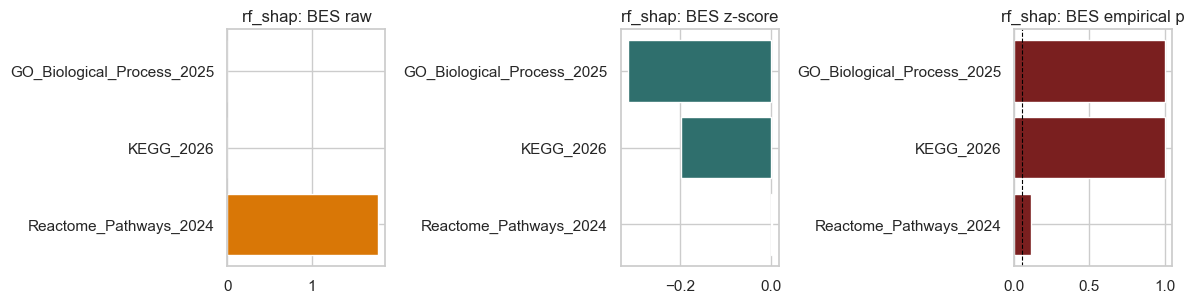

In [187]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, (metric, color, title) in zip(axes, [
    ("bes_raw", PALETTE["primary"],  "BES raw"),
    ("bes_z",   PALETTE["secondary"], "BES z-score"),
    ("bes_p_emp", PALETTE["danger"], "BES empirical p"),
]):
    ax.barh(bes_df["library"], bes_df[metric], color=color)
    ax.set_title(f"{METHOD}: {title}")
    ax.invert_yaxis()
axes[2].axvline(0.05, color="black", ls="--", lw=0.8)
fig.tight_layout()
plt.show()

In [188]:
TOP_N_TERMS = 20

with pd.option_context("display.max_colwidth", None):
    for lib in libraries:
        terms = pd.read_parquet(STAGE_DIRS["enrichment"] / lib / "terms.parquet")
        sig = terms[terms["q_value"] < 0.05].sort_values("q_value")
        print(f"\n### {lib}: {len(sig)} terms q<0.05 (of {len(terms)})")

        show = (sig if len(sig) else terms.sort_values("q_value")).head(TOP_N_TERMS)
        display(show[["term", "q_value", "p_value", "overlap_size", "term_size", "genes"]].round(4))


### GO_Biological_Process_2025: 0 terms q<0.05 (of 126)


,term,q_value,p_value,overlap_size,term_size,genes
0,Definitive Hemopoiesis (GO:0060216),0.0631,0.0038,1,6.0,MFAP5
1,Amino-Acid Betaine Metabolic Process (GO:0006577),0.0631,0.0050,1,6.0,CROT
2,Glucose Mediated Signaling Pathway (GO:0010255),0.0631,0.0050,1,6.0,AGER
3,Hexose Mediated Signaling (GO:0009757),0.0631,0.0050,1,6.0,AGER
4,Regulation of Osteoclast Development (GO:2001204),0.0631,0.0050,1,6.0,SIGLEC15
5,4-Hydroxyproline Metabolic Process (GO:0019471),0.0631,0.0063,1,5.0,GOT2
6,Embryonic Eye Morphogenesis (GO:0048048),0.0631,0.0063,1,9.0,MFAP5
7,Malate-Aspartate Shuttle (GO:0043490),0.0631,0.0063,1,8.0,GOT2
8,Aspartate Family Amino Acid Metabolic Process (GO:0009066),0.0631,0.0075,1,10.0,GOT2
9,Response to Ethanol (GO:0045471),0.0631,0.0075,1,17.0,GOT2



### KEGG_2026: 0 terms q<0.05 (of 24)


,term,q_value,p_value,overlap_size,term_size,genes
0,"PHENYLALANINE, TYROSINE AND TRYPTOPHAN BIOSYNTHESIS",0.0696,0.0038,1,6.0,GOT2
1,PHENYLALANINE METABOLISM,0.0696,0.0126,1,16.0,GOT2
2,LIPOIC ACID METABOLISM,0.0696,0.0163,1,19.0,AMT
3,ARGININE BIOSYNTHESIS,0.0696,0.0213,1,22.0,GOT2
4,ASCORBATE AND ALDARATE METABOLISM,0.0696,0.0262,1,31.0,RGN
5,PENTOSE PHOSPHATE PATHWAY,0.0696,0.0262,1,30.0,RGN
6,GLYOXYLATE AND DICARBOXYLATE METABOLISM,0.0696,0.0299,1,31.0,AMT
7,TYROSINE METABOLISM,0.0696,0.0323,1,36.0,GOT2
8,FAT DIGESTION AND ABSORPTION,0.0696,0.0336,1,43.0,GOT2
9,ONE CARBON POOL BY FOLATE,0.0696,0.0336,1,36.0,AMT



### Reactome_Pathways_2024: 0 terms q<0.05 (of 24)


,term,q_value,p_value,overlap_size,term_size,genes
0,"PHENYLALANINE, TYROSINE AND TRYPTOPHAN BIOSYNTHESIS",0.0696,0.0038,1,6.0,GOT2
1,PHENYLALANINE METABOLISM,0.0696,0.0126,1,16.0,GOT2
2,LIPOIC ACID METABOLISM,0.0696,0.0163,1,19.0,AMT
3,ARGININE BIOSYNTHESIS,0.0696,0.0213,1,22.0,GOT2
4,ASCORBATE AND ALDARATE METABOLISM,0.0696,0.0262,1,31.0,RGN
5,PENTOSE PHOSPHATE PATHWAY,0.0696,0.0262,1,30.0,RGN
6,GLYOXYLATE AND DICARBOXYLATE METABOLISM,0.0696,0.0299,1,31.0,AMT
7,TYROSINE METABOLISM,0.0696,0.0323,1,36.0,GOT2
8,FAT DIGESTION AND ABSORPTION,0.0696,0.0336,1,43.0,GOT2
9,ONE CARBON POOL BY FOLATE,0.0696,0.0336,1,36.0,AMT
